Clustering Analysis (Unsupervised Learning)

Using three approaches:
1. PCA biplot -> visualise structure in PC space, colored by true status
2. K-means clustering -> silhouette analysis to choose k value, then k=2 evaluation against true labels
3. Hierarchical clustering -> Ward-linkage dendrogram colored by true status

All features are log-transformed (skewed variables) and standardised before clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    adjusted_rand_score, silhouette_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

COL_PD      = '#ca3335'   # red — PD
COL_HEALTHY = '#467ba7'   # blue — healthy
COL_C0      = '#e08b3b'   # cluster 0
COL_C1      = '#5a9e6f'   # cluster 1

# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv('../data/2025_parkinsons.csv')
df['subject'] = df['name'].str.rsplit('_', n=1).str[0]
df = df.dropna().reset_index(drop=True)

features = [c for c in df.columns if c not in ['name', 'subject', 'status']]
y_true   = df['status'].values.astype(int)   # 1 = PD, 0 = Healthy

print(f'Recordings: {len(df)}  |  Features: {len(features)}')
print(f'PD: {(y_true==1).sum()}  |  Healthy: {(y_true==0).sum()}')


Recordings: 185  |  Features: 22
PD: 141  |  Healthy: 44


In [2]:
# Log-transform skewed features (same list as modelling notebooks)
LOG_FEATS = [
    'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
    'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA',
    'NHR', 'RPDE', 'D2', 'PPE',
]

X_raw = df[features].copy()
for f in LOG_FEATS:
    if f in X_raw.columns and (X_raw[f] > 0).all():
        X_raw[f] = np.log(X_raw[f])

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA for visualisation and biplot
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
ev_ratio = pca.explained_variance_ratio_

print(f'PC1 explains {ev_ratio[0]*100:.1f}% of variance')
print(f'PC2 explains {ev_ratio[1]*100:.1f}% of variance')
print(f'PC1+PC2 combined: {(ev_ratio[0]+ev_ratio[1])*100:.1f}%')
print(f'PCs needed to explain 80%: {(np.cumsum(ev_ratio) < 0.80).sum() + 1}')


PC1 explains 59.0% of variance
PC2 explains 11.0% of variance
PC1+PC2 combined: 70.1%
PCs needed to explain 80%: 4


1. PCA Biplot

PC1 vs PC2 colored by true diagnosis. Arrows show the direction and strength of each feature's contribution (loading vectors). 

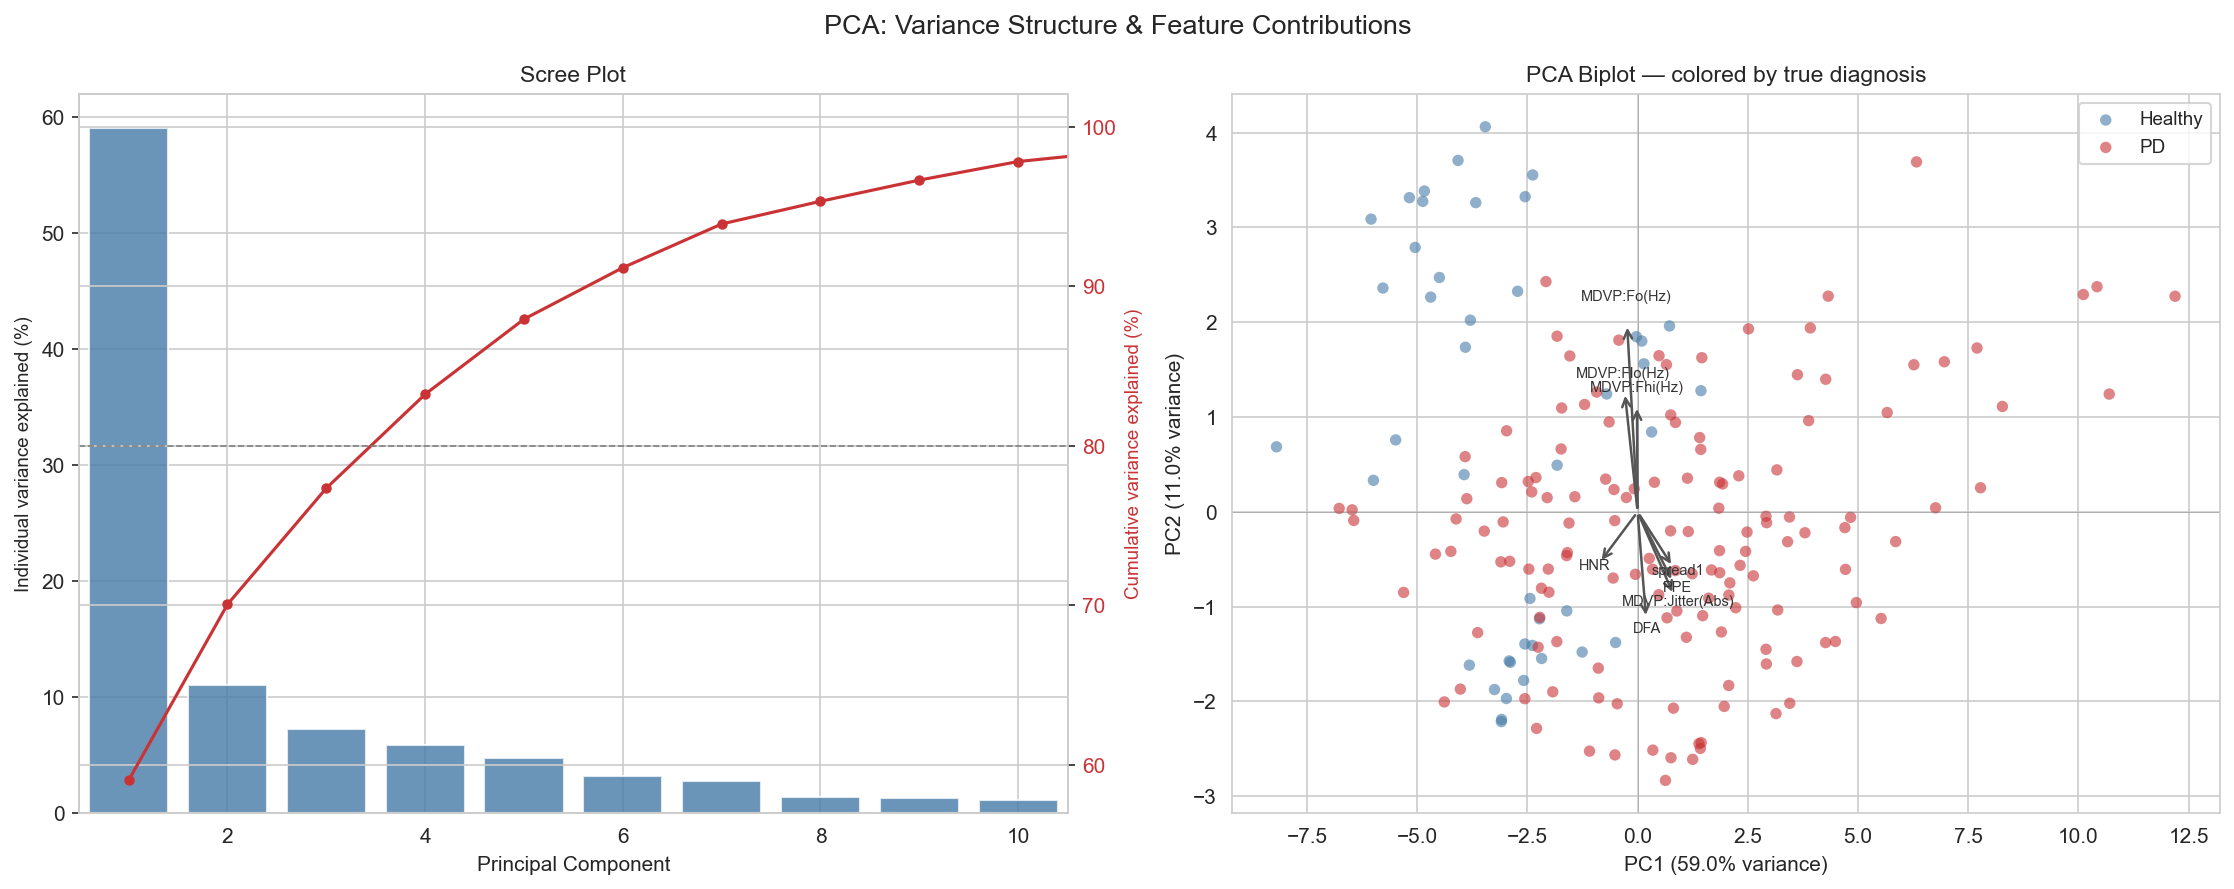

In [3]:
# ── Scree plot + PCA biplot side by side ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Scree plot ---
ax = axes[0]
cumvar = np.cumsum(ev_ratio)
ax.bar(range(1, len(ev_ratio)+1), ev_ratio*100,
       color=COL_HEALTHY, alpha=0.8, edgecolor='white', label='Individual')
ax2 = ax.twinx()
ax2.plot(range(1, len(ev_ratio)+1), cumvar*100,
         color=COL_PD, marker='o', markersize=4, linewidth=1.5, label='Cumulative')
ax2.axhline(80, color='grey', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Cumulative variance explained (%)', color=COL_PD, fontsize=9)
ax2.tick_params(axis='y', labelcolor=COL_PD)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Individual variance explained (%)', fontsize=9)
ax.set_title('Scree Plot', fontsize=11)
ax.set_xlim(0.5, min(10, len(ev_ratio)) + 0.5)

# --- PCA biplot ---
ax = axes[1]

# scatter by true label
for g, label, color in [(0, 'Healthy', COL_HEALTHY), (1, 'PD', COL_PD)]:
    m = y_true == g
    ax.scatter(X_pca[m, 0], X_pca[m, 1],
               c=color, label=label, alpha=0.6, s=30, edgecolors='none')

# loading vectors — top 8 by magnitude in PC1/PC2 plane
loadings = pca.components_[:2].T   # shape (n_features, 2)
magnitudes = np.linalg.norm(loadings, axis=1)
top_idx = np.argsort(magnitudes)[::-1][:8]

scale = 3.5  # scale arrows to fit plot
for i in top_idx:
    ax.annotate('', xy=(loadings[i,0]*scale, loadings[i,1]*scale), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.2))
    ax.text(loadings[i,0]*scale*1.12, loadings[i,1]*scale*1.12,
            features[i], fontsize=7, color='#333333', ha='center')

ax.set_xlabel(f'PC1 ({ev_ratio[0]*100:.1f}% variance)', fontsize=10)
ax.set_ylabel(f'PC2 ({ev_ratio[1]*100:.1f}% variance)', fontsize=10)
ax.set_title('PCA Biplot — colored by true diagnosis', fontsize=11)
ax.legend(fontsize=9)
ax.axhline(0, color='grey', linewidth=0.4, alpha=0.5)
ax.axvline(0, color='grey', linewidth=0.4, alpha=0.5)

fig.suptitle('PCA: Variance Structure & Feature Contributions', fontsize=13)
plt.tight_layout()
plt.savefig('../plots/clustering_pca_biplot.png', dpi=200, bbox_inches='tight')
plt.show()


2. K-Means Clustering

-> first choosing k:
We test k = 2 … 8. Looking at the silhouette score and elbow method

Best silhouette score: 0.312 at k=2
  k=2  silhouette=0.312
  k=3  silhouette=0.255
  k=4  silhouette=0.228
  k=5  silhouette=0.237
  k=6  silhouette=0.215
  k=7  silhouette=0.195
  k=8  silhouette=0.195


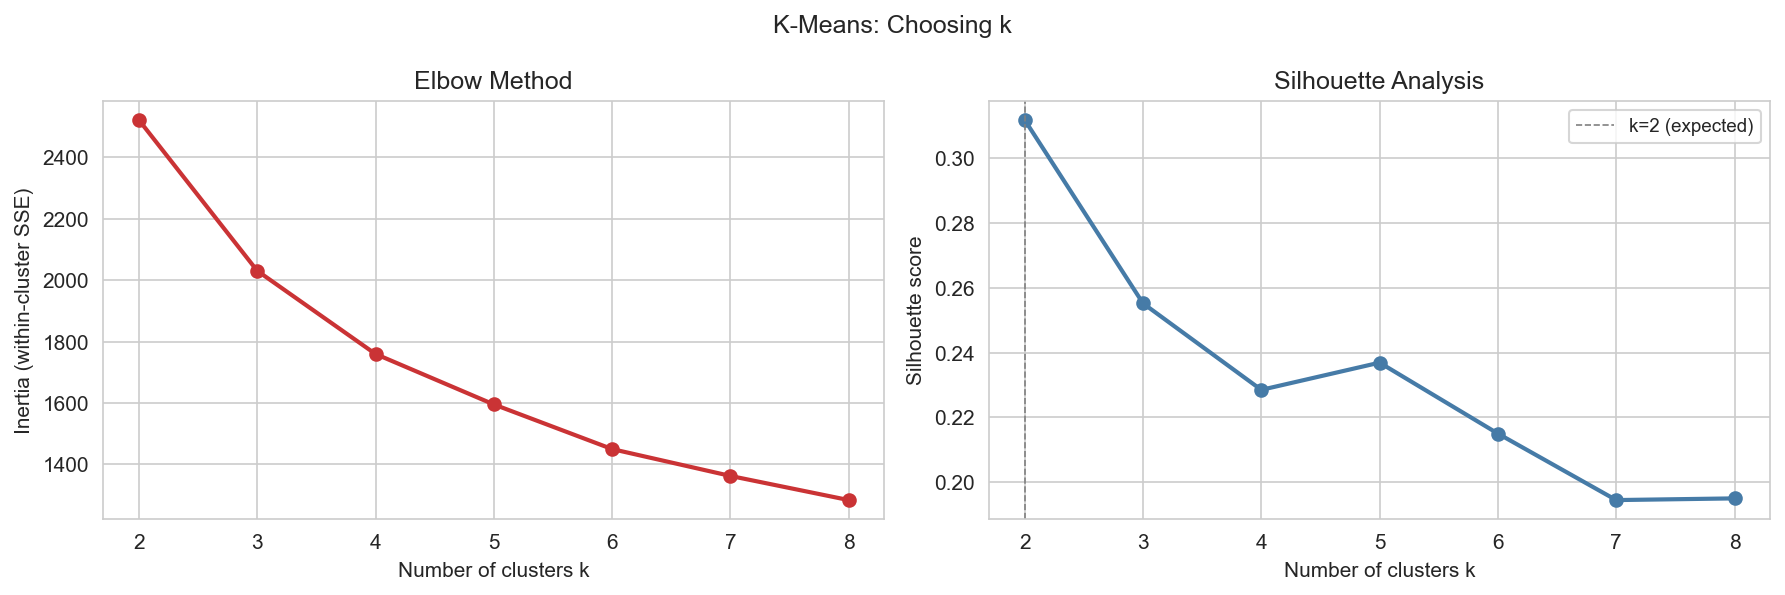

In [4]:
k_range     = range(2, 9)
inertias    = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, 'o-', color=COL_PD, linewidth=2)
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouettes, 'o-', color=COL_HEALTHY, linewidth=2)
axes[1].axvline(2, color='grey', linestyle='--', linewidth=0.8, label='k=2 (expected)')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Analysis')
axes[1].set_xticks(list(k_range))
axes[1].legend(fontsize=9)

best_k = list(k_range)[np.argmax(silhouettes)]
print(f'Best silhouette score: {max(silhouettes):.3f} at k={best_k}')
for k, s in zip(k_range, silhouettes):
    print(f'  k={k}  silhouette={s:.3f}')

fig.suptitle('K-Means: Choosing k', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/clustering_silhouette.png', dpi=200, bbox_inches='tight')
plt.show()


-> second: K-Means with k = 2

Parkinson's / healthy labels using:
- Adjusted Rand Index (ARI): chance-corrected agreement (0 = random, 1 = perfect)
- Cluster purity: majority-class fraction within each cluster
- Confusion matrix between cluster labels and true status (best alignment permutation)


K-Means k=2 results
  Adjusted Rand Index (ARI) : 0.118
  Silhouette score          : 0.312
  Cluster purity            : 0.762

Cluster composition:
  Cluster 0: 85 recordings — PD=83, Healthy=2
  Cluster 1: 100 recordings — PD=58, Healthy=42


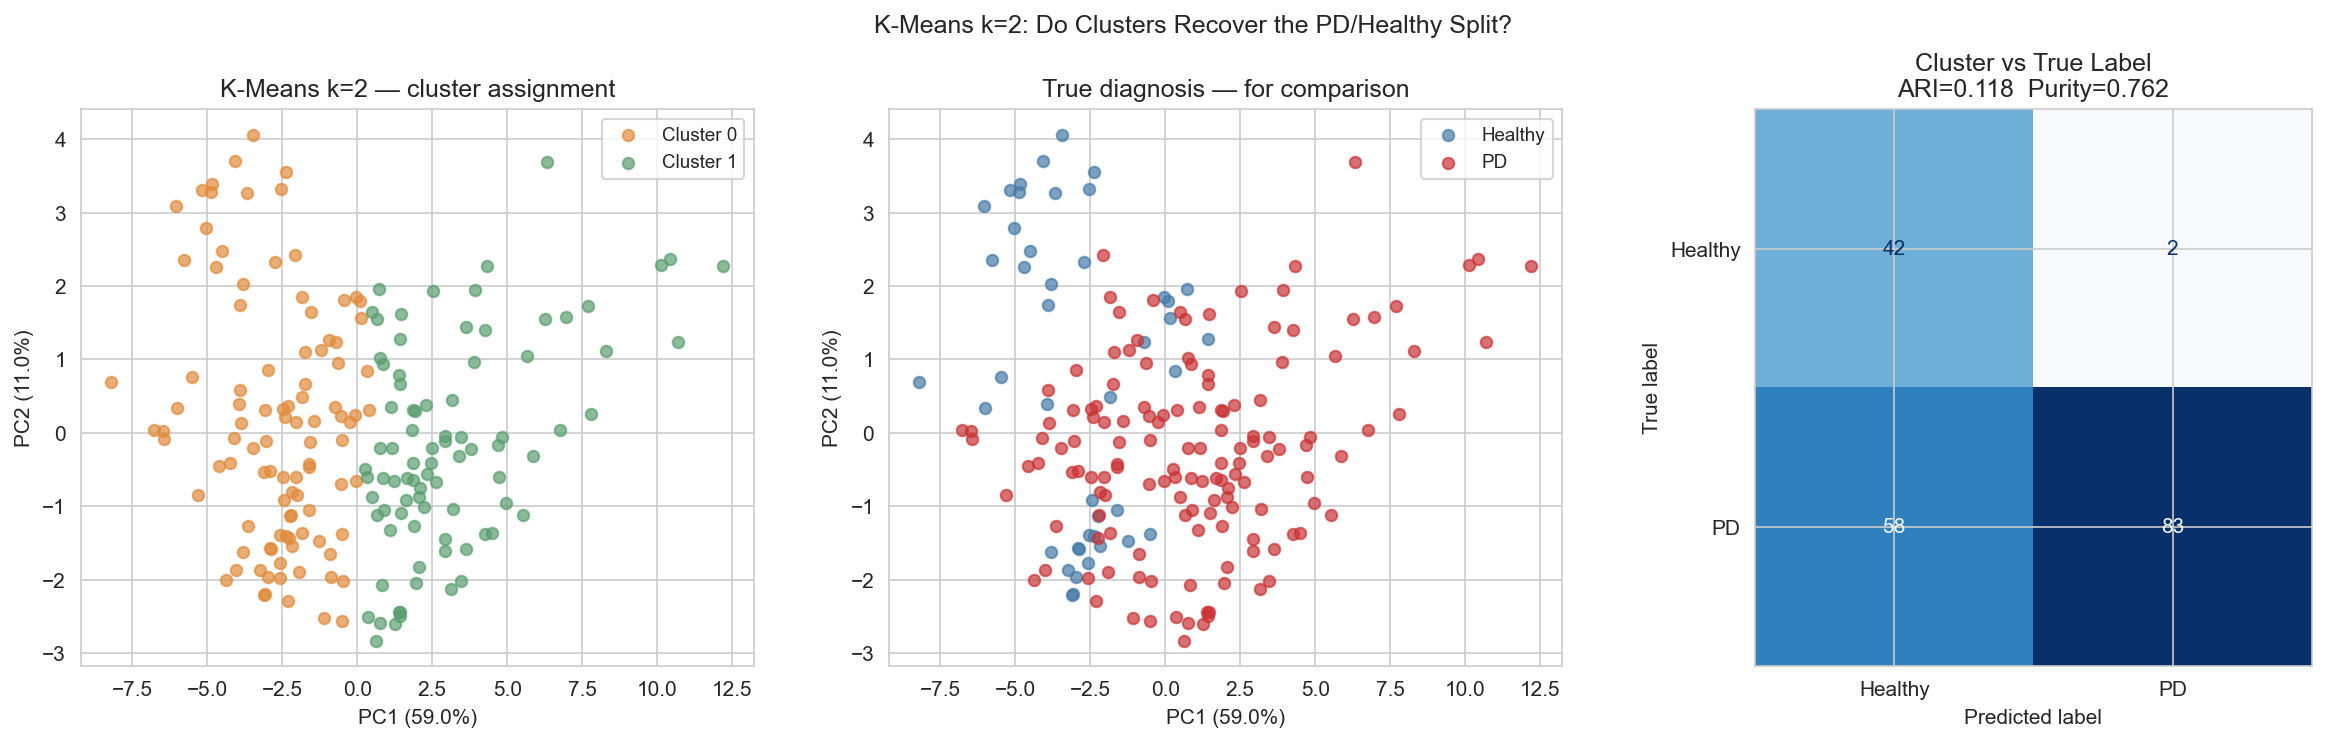

In [5]:
km2 = KMeans(n_clusters=2, random_state=42, n_init=50)
cluster_labels = km2.fit_predict(X_scaled)

ari = adjusted_rand_score(y_true, cluster_labels)
sil = silhouette_score(X_scaled, cluster_labels)

# Purity: for each cluster, majority class fraction
def cluster_purity(y_true, cluster_labels):
    total = 0
    for c in np.unique(cluster_labels):
        mask = cluster_labels == c
        total += np.bincount(y_true[mask]).max()
    return total / len(y_true)

purity = cluster_purity(y_true, cluster_labels)

# Best-alignment confusion matrix (try both permutations)
cm0 = confusion_matrix(y_true, cluster_labels)
cm1 = confusion_matrix(y_true, 1 - cluster_labels)
acc0 = (cm0[0,0] + cm0[1,1]) / cm0.sum()
acc1 = (cm1[0,0] + cm1[1,1]) / cm1.sum()
best_cm = cm0 if acc0 >= acc1 else cm1
best_labels = cluster_labels if acc0 >= acc1 else 1 - cluster_labels

print(f'K-Means k=2 results')
print(f'  Adjusted Rand Index (ARI) : {ari:.3f}')
print(f'  Silhouette score          : {sil:.3f}')
print(f'  Cluster purity            : {purity:.3f}')
print()
print('Cluster composition:')
for c in [0, 1]:
    mask = cluster_labels == c
    n_pd = (y_true[mask] == 1).sum()
    n_he = (y_true[mask] == 0).sum()
    print(f'  Cluster {c}: {mask.sum()} recordings — PD={n_pd}, Healthy={n_he}')

# ── Figure: PCA scatter (clusters) + confusion matrix ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: PCA colored by CLUSTER
ax = axes[0]
for c, label, color in [(0, 'Cluster 0', COL_C0), (1, 'Cluster 1', COL_C1)]:
    m = best_labels == c
    ax.scatter(X_pca[m, 0], X_pca[m, 1], c=color, label=label, alpha=0.7, s=30)
ax.set_xlabel(f'PC1 ({ev_ratio[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({ev_ratio[1]*100:.1f}%)')
ax.set_title('K-Means k=2 — cluster assignment')
ax.legend(fontsize=9)

# Middle: PCA colored by TRUE LABEL
ax = axes[1]
for g, label, color in [(0, 'Healthy', COL_HEALTHY), (1, 'PD', COL_PD)]:
    m = y_true == g
    ax.scatter(X_pca[m, 0], X_pca[m, 1], c=color, label=label, alpha=0.7, s=30)
ax.set_xlabel(f'PC1 ({ev_ratio[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({ev_ratio[1]*100:.1f}%)')
ax.set_title('True diagnosis — for comparison')
ax.legend(fontsize=9)

# Right: confusion matrix
ax = axes[2]
disp = ConfusionMatrixDisplay(best_cm, display_labels=['Healthy', 'PD'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Cluster vs True Label\nARI={ari:.3f}  Purity={purity:.3f}')

fig.suptitle('K-Means k=2: Do Clusters Recover the PD/Healthy Split?', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/clustering_kmeans_k2.png', dpi=200, bbox_inches='tight')
plt.show()


## 3. Hierarchical Clustering

Ward linkage minimises within-cluster variance and is generally the best performing
linkage criterion for compact, reasonably sized clusters. We build a dendrogram over
all recordings and color the leaves by true diagnosis to visualise how well the
hierarchy separates PD from healthy.


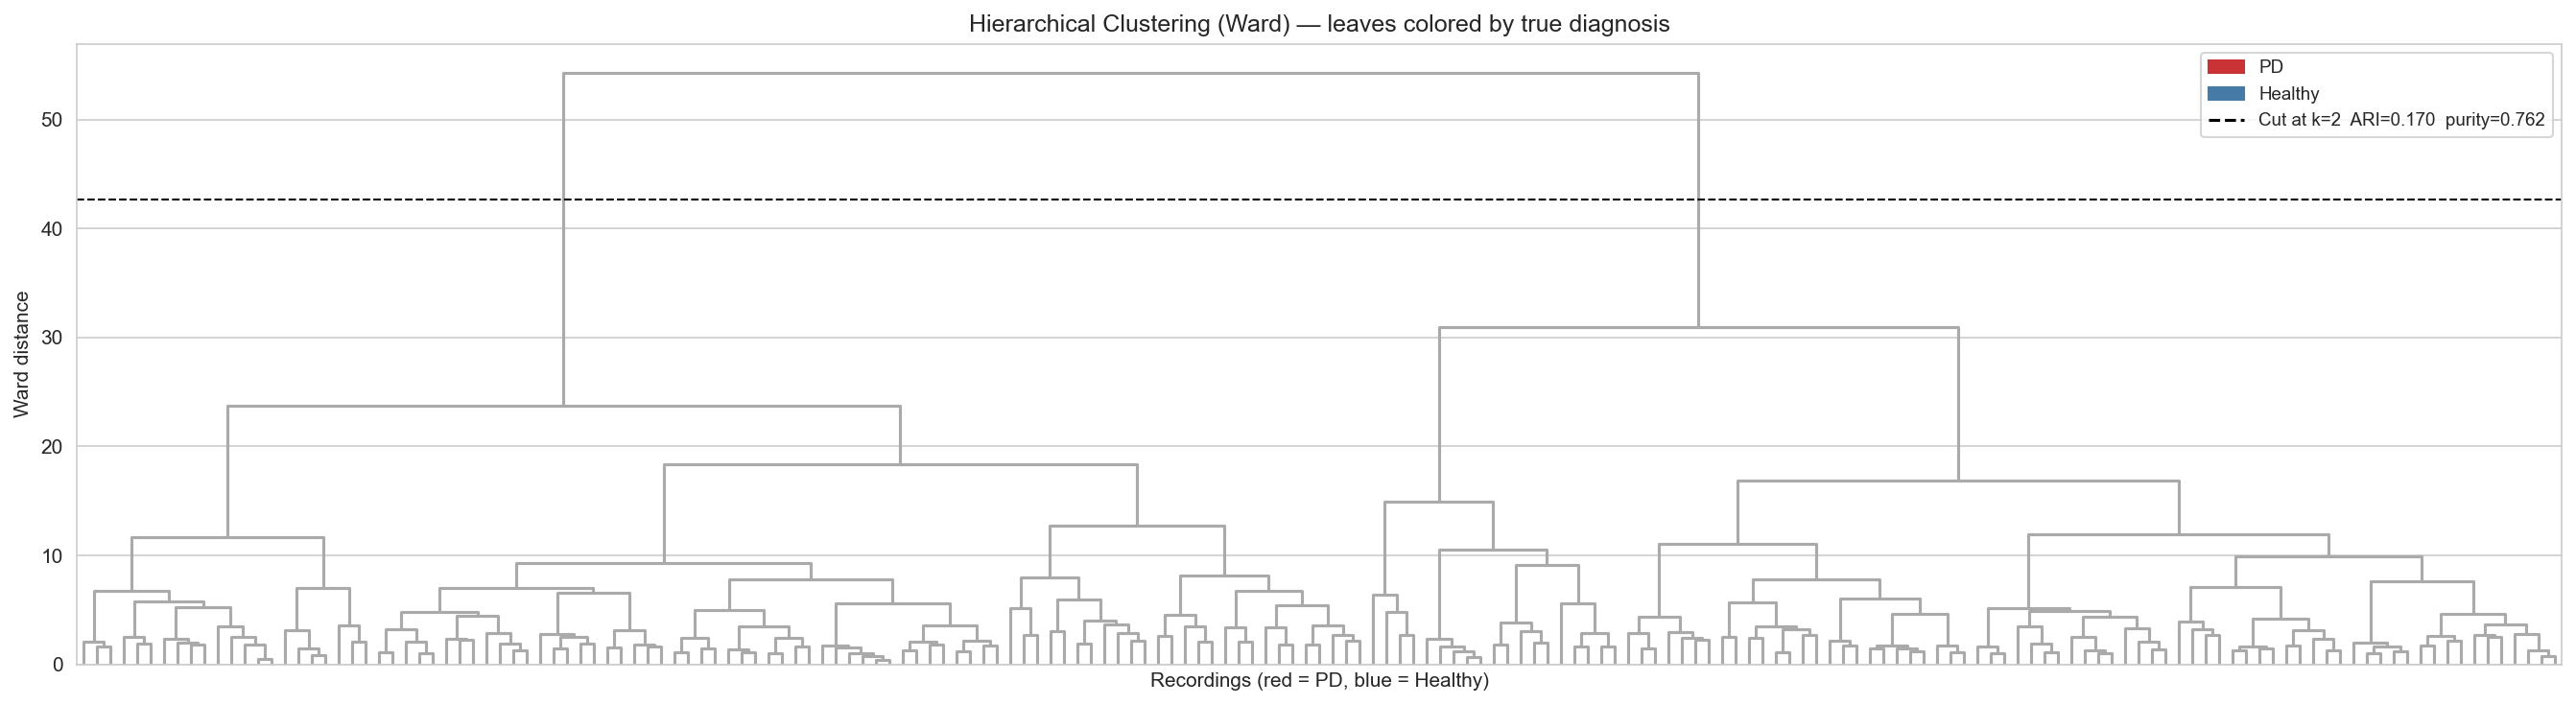

Hierarchical clustering (Ward, k=2):
  ARI     : 0.170
  Purity  : 0.762

  Cluster 0: 89 recordings — PD=88, Healthy=1
  Cluster 1: 96 recordings — PD=53, Healthy=43


In [6]:
Z = linkage(X_scaled, method='ward')

# Leaf colors by true status
leaf_colors = {i: (COL_PD if y_true[i] == 1 else COL_HEALTHY)
               for i in range(len(y_true))}

def color_func(id):
    if id < len(y_true):   # leaf node
        return leaf_colors[id]
    return '#888888'        # internal node

fig, ax = plt.subplots(figsize=(18, 5))
dn = dendrogram(
    Z,
    ax=ax,
    link_color_func=lambda k: '#aaaaaa',
    leaf_rotation=90,
    leaf_font_size=4,
    no_labels=True,
)

# Color leaf tick-marks by status
xlabels = ax.get_xmajorticklabels()
leaf_order = dn['leaves']
for tick, leaf_idx in zip(xlabels, leaf_order):
    tick.set_color(leaf_colors[leaf_idx])

# Cut at k=2 — horizontal line
hc2 = AgglomerativeClustering(n_clusters=2, linkage='ward')
hc_labels = hc2.fit_predict(X_scaled)
hc_ari = adjusted_rand_score(y_true, hc_labels)
hc_purity = cluster_purity(y_true, hc_labels)

cut_height = (Z[-1, 2] + Z[-2, 2]) / 2
ax.axhline(cut_height, color='black', linestyle='--', linewidth=1,
           label=f'Cut at k=2  (ARI={hc_ari:.3f}, purity={hc_purity:.3f})')
ax.legend(fontsize=9, loc='upper right')

pd_patch  = mpatches.Patch(color=COL_PD,      label='PD')
he_patch  = mpatches.Patch(color=COL_HEALTHY, label='Healthy')
ax.legend(handles=[pd_patch, he_patch,
                   plt.Line2D([0],[0], color='black', linestyle='--',
                              label=f'Cut at k=2  ARI={hc_ari:.3f}  purity={hc_purity:.3f}')],
          fontsize=9, loc='upper right')

ax.set_title('Hierarchical Clustering (Ward) — leaves colored by true diagnosis', fontsize=12)
ax.set_xlabel('Recordings (red = PD, blue = Healthy)', fontsize=10)
ax.set_ylabel('Ward distance', fontsize=10)

plt.tight_layout()
plt.savefig('../plots/clustering_dendrogram.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Hierarchical clustering (Ward, k=2):')
print(f'  ARI     : {hc_ari:.3f}')
print(f'  Purity  : {hc_purity:.3f}')
print()
for c in [0, 1]:
    mask = hc_labels == c
    n_pd = (y_true[mask] == 1).sum()
    n_he = (y_true[mask] == 0).sum()
    print(f'  Cluster {c}: {mask.sum()} recordings — PD={n_pd}, Healthy={n_he}')


## 4. Summary


In [8]:
summary = pd.DataFrame([
    {
        'Method':          'K-Means (k=2)',
        'ARI':             round(ari, 3),
        'Silhouette':      round(sil, 3),
        'Purity':          round(purity, 3),
    },
    {
        'Method':          'Hierarchical/Ward (k=2)',
        'ARI':             round(hc_ari, 3),
        'Silhouette':      round(silhouette_score(X_scaled, hc_labels), 3),
        'Purity':          round(hc_purity, 3),
    },
])
summary = summary.set_index('Method')
print('Clustering Summary')
print(summary.to_string())
print()
print('ARI interpretation:')
print('  > 0.6  : strong recovery of true labels')
print('  0.3–0.6: moderate recovery')
print('  < 0.3  : weak recovery (clusters differ from true labels)')
print()
print('Baseline purity (always predicting majority class): '
      f'{max((y_true==1).mean(), (y_true==0).mean()):.3f}')


Clustering Summary
                           ARI  Silhouette  Purity
Method                                            
K-Means (k=2)            0.118       0.312   0.762
Hierarchical/Ward (k=2)  0.170       0.294   0.762

ARI interpretation:
  > 0.6  : strong recovery of true labels
  0.3–0.6: moderate recovery
  < 0.3  : weak recovery (clusters differ from true labels)

Baseline purity (always predicting majority class): 0.762


- If ARI is high (> 0.5): the vocal features naturally separate PD from healthy,
  which strongly supports the discriminative power of the feature set and motivates
  the supervised modelling approach.
- If ARI is moderate (0.2–0.5): partial structure exists — the PD group is heterogeneous
  (consistent with the variable nature of the disease), but the core signal is present.
- If ARI is low (< 0.2): unsupervised structure does not align with diagnosis,
  suggesting the decision boundary is non-linear or the feature space mixes groups.

Purity is an upper-bound optimistic metric (it assigns the best
possible majority label to each cluster), so ARI is the more honest comparison.
The silhouette score reflects the internal cluster quality independent of labels;
a higher score means more compact, well-separated clusters.
